In [2]:
# ============================================================
# CELL 1 - Install & Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")




✅ All libraries imported successfully!


In [3]:
# ============================================================
# CELL 2 - Create Dataset
# (No download needed - dataset is created automatically)
# ============================================================

np.random.seed(42)
n_students = 1000

data = {
    'study_hours_per_day': np.random.uniform(0, 10, n_students).round(1),
    'attendance_percentage': np.random.uniform(40, 100, n_students).round(1),
    'previous_score': np.random.uniform(30, 100, n_students).round(1),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'assignments_completed': np.random.randint(0, 20, n_students),
    'gender': np.random.choice(['Male', 'Female'], n_students),
    'part_time_job': np.random.choice(['Yes', 'No'], n_students),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students),
}

df = pd.DataFrame(data)

# Calculate exam score based on features
df['exam_score'] = (
    df['study_hours_per_day'] * 4.5 +
    df['attendance_percentage'] * 0.3 +
    df['previous_score'] * 0.25 +
    df['sleep_hours'] * 1.2 +
    df['assignments_completed'] * 0.8 +
    np.random.normal(0, 5, n_students)
).clip(0, 100).round(1)

# Create pass/fail label (pass = score >= 50)
df['result'] = df['exam_score'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

print("✅ Dataset created successfully!")
print(f"Total students : {len(df)}")
print(f"\nClass distribution:")
print(df['result'].value_counts())
print(f"\nSample data:")
print(df.head())
print(f"\nBasic statistics:")
print(df.describe().round(2))



✅ Dataset created successfully!
Total students : 1000

Class distribution:
result
Pass    930
Fail     70
Name: count, dtype: int64

Sample data:
   study_hours_per_day  attendance_percentage  previous_score  sleep_hours  \
0                  3.7                   51.1            48.3          8.0   
1                  9.5                   72.5            47.3          8.8   
2                  7.3                   92.4            93.4          5.5   
3                  6.0                   83.9            47.5          7.7   
4                  1.6                   88.4            49.0          7.4   

   assignments_completed  gender part_time_job extracurricular  exam_score  \
0                      9  Female            No             Yes        61.6   
1                      4  Female            No              No        91.5   
2                     19    Male            No              No       100.0   
3                     19    Male           Yes             Yes        93.

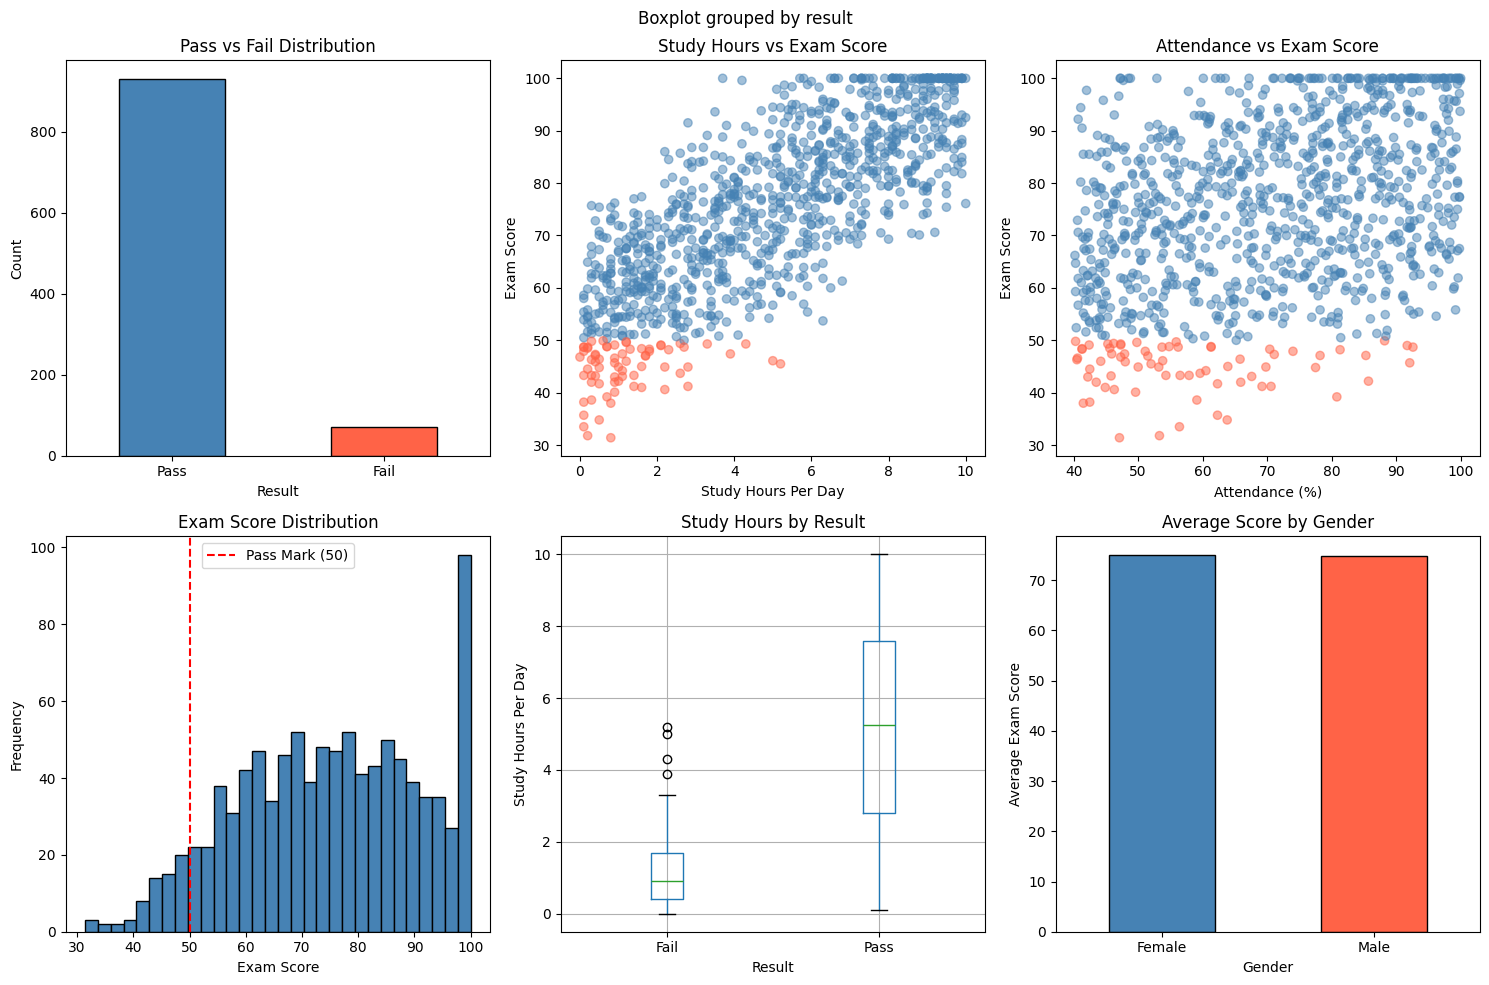

✅ EDA charts saved as eda_plots.png


In [4]:
# ============================================================
# CELL 3 - Exploratory Data Analysis (EDA)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Student Performance - Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# Plot 1: Pass/Fail Distribution
df['result'].value_counts().plot(
    kind='bar', ax=axes[0, 0],
    color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0, 0].set_title('Pass vs Fail Distribution')
axes[0, 0].set_xlabel('Result')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(rotation=0)

# Plot 2: Study Hours vs Exam Score
axes[0, 1].scatter(
    df['study_hours_per_day'], df['exam_score'],
    c=df['result'].map({'Pass': 'steelblue', 'Fail': 'tomato'}),
    alpha=0.5
)
axes[0, 1].set_title('Study Hours vs Exam Score')
axes[0, 1].set_xlabel('Study Hours Per Day')
axes[0, 1].set_ylabel('Exam Score')

# Plot 3: Attendance vs Exam Score
axes[0, 2].scatter(
    df['attendance_percentage'], df['exam_score'],
    c=df['result'].map({'Pass': 'steelblue', 'Fail': 'tomato'}),
    alpha=0.5
)
axes[0, 2].set_title('Attendance vs Exam Score')
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Exam Score')

# Plot 4: Exam Score Distribution
axes[1, 0].hist(df['exam_score'], bins=30,
                color='steelblue', edgecolor='black')
axes[1, 0].axvline(x=50, color='red',
                   linestyle='--', label='Pass Mark (50)')
axes[1, 0].set_title('Exam Score Distribution')
axes[1, 0].set_xlabel('Exam Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 5: Study Hours by Result
df.boxplot(column='study_hours_per_day',
           by='result', ax=axes[1, 1])
axes[1, 1].set_title('Study Hours by Result')
axes[1, 1].set_xlabel('Result')
axes[1, 1].set_ylabel('Study Hours Per Day')

# Plot 6: Average Score by Gender
df.groupby('gender')['exam_score'].mean().plot(
    kind='bar', ax=axes[1, 2],
    color=['steelblue', 'tomato'], edgecolor='black'
)
axes[1, 2].set_title('Average Score by Gender')
axes[1, 2].set_xlabel('Gender')
axes[1, 2].set_ylabel('Average Exam Score')
axes[1, 2].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved as eda_plots.png")


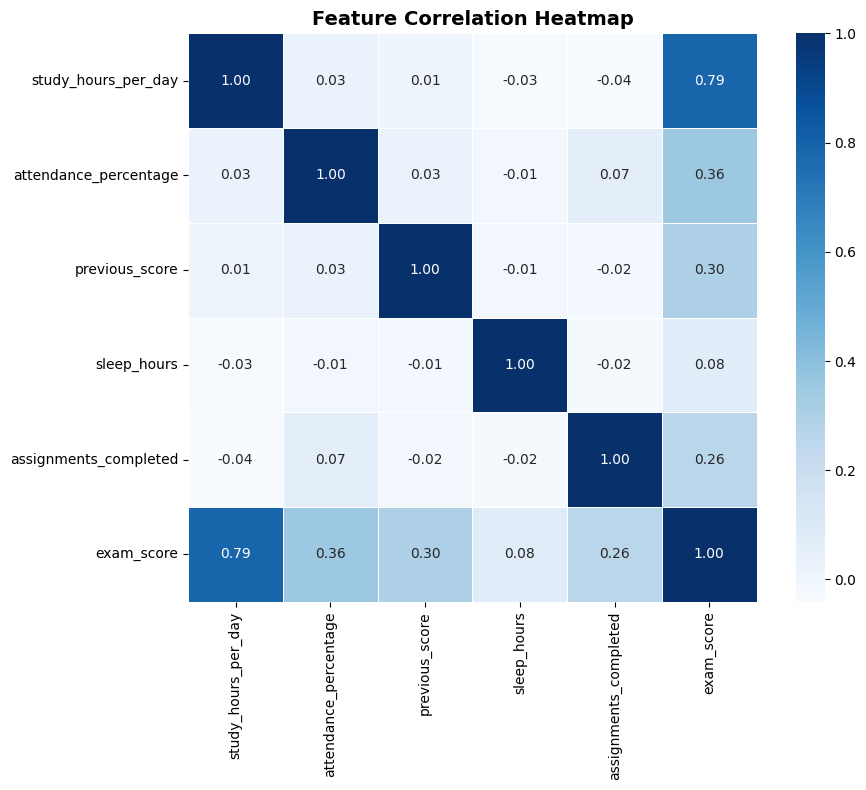

✅ Correlation heatmap saved as correlation_heatmap.png

Top correlations with exam_score:
exam_score               1.000000
study_hours_per_day      0.785078
attendance_percentage    0.357413
previous_score           0.302223
assignments_completed    0.258523
sleep_hours              0.080969
Name: exam_score, dtype: float64


In [5]:
# ============================================================
# CELL 4 - Correlation Heatmap
# ============================================================

plt.figure(figsize=(10, 8))
numeric_cols = ['study_hours_per_day', 'attendance_percentage',
                'previous_score', 'sleep_hours',
                'assignments_completed', 'exam_score']
correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True, fmt='.2f',
    cmap='Blues',
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved as correlation_heatmap.png")
print("\nTop correlations with exam_score:")
print(correlation['exam_score'].sort_values(ascending=False))


In [6]:
# ============================================================
# CELL 5 - Preprocessing & Feature Engineering
# ============================================================

df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
df_model['gender_encoded']       = le.fit_transform(df_model['gender'])
df_model['part_time_encoded']    = le.fit_transform(df_model['part_time_job'])
df_model['extracurricular_enc']  = le.fit_transform(df_model['extracurricular'])
df_model['result_encoded']       = le.fit_transform(df_model['result'])

# Feature columns
feature_cols = [
    'study_hours_per_day', 'attendance_percentage',
    'previous_score', 'sleep_hours',
    'assignments_completed', 'gender_encoded',
    'part_time_encoded', 'extracurricular_enc'
]

X = df_model[feature_cols]
y = df_model['result_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2,
    random_state=42, stratify=y
)

print("✅ Preprocessing complete!")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Features used    : {len(feature_cols)}")



✅ Preprocessing complete!
Training samples : 800
Testing samples  : 200
Features used    : 8


In [7]:
# ============================================================
# CELL 6 - Train Multiple Models
# ============================================================

models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(random_state=42)
}

results = {}
label_names = ['Fail', 'Pass']

print("=" * 60)
print("TRAINING MULTIPLE ML ALGORITHMS")
print("=" * 60)

for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=label_names))



TRAINING MULTIPLE ML ALGORITHMS

--- Training: Logistic Regression ---
Accuracy: 97.50%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.91      0.71      0.80        14
        Pass       0.98      0.99      0.99       186

    accuracy                           0.97       200
   macro avg       0.94      0.85      0.89       200
weighted avg       0.97      0.97      0.97       200


--- Training: Random Forest ---
Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.75      0.21      0.33        14
        Pass       0.94      0.99      0.97       186

    accuracy                           0.94       200
   macro avg       0.85      0.60      0.65       200
weighted avg       0.93      0.94      0.92       200


--- Training: Support Vector Machine ---
Accuracy: 95.50%

Classification Report:
              precision    recall  f1-score   support

        Fail       1.0

In [8]:
# ============================================================
# CELL 7 - Compare Models & Select Best
# ============================================================

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
for name, acc in sorted(results.items(),
                         key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 30)
    print(f"{name:<30} {acc*100:.2f}%  {bar}")

best_model_name = max(results, key=results.get)
best_model      = models[best_model_name]
best_accuracy   = results[best_model_name]

print(f"\n✅ BEST MODEL   : {best_model_name}")
print(f"   Best Accuracy: {best_accuracy*100:.2f}%")



MODEL COMPARISON
Logistic Regression            97.50%  █████████████████████████████
Support Vector Machine         95.50%  ████████████████████████████
Gradient Boosting              95.00%  ████████████████████████████
Random Forest                  94.00%  ████████████████████████████

✅ BEST MODEL   : Logistic Regression
   Best Accuracy: 97.50%


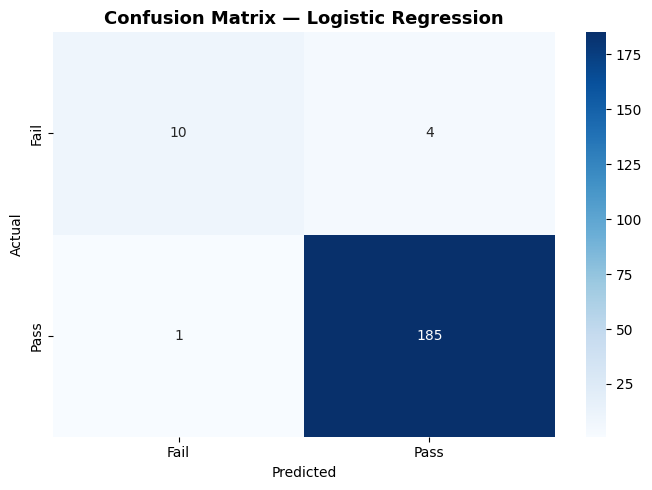

✅ Confusion matrix saved as confusion_matrix.png


In [9]:
# ============================================================
# CELL 8 - Confusion Matrix
# ============================================================

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title(f'Confusion Matrix — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")



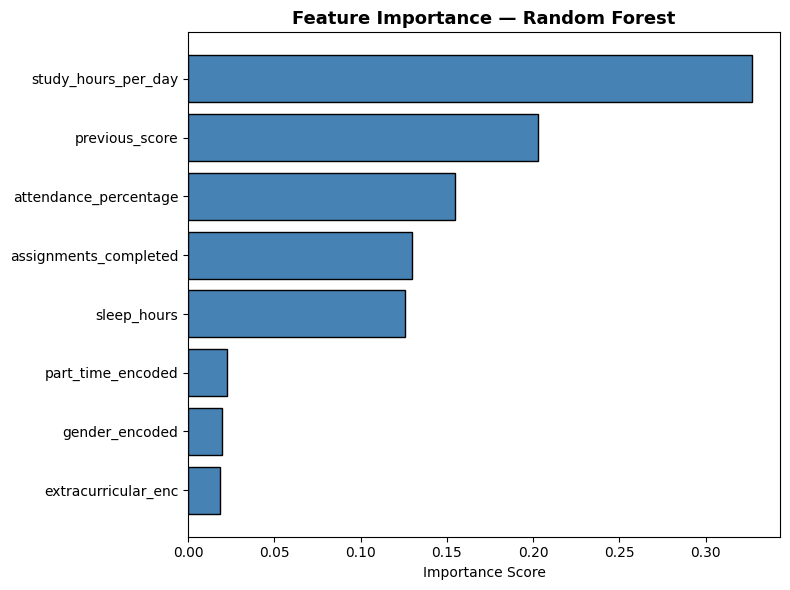

✅ Feature importance chart saved as feature_importance.png

Top 3 most important features:
                 Feature  Importance
0    study_hours_per_day    0.326703
2         previous_score    0.202786
1  attendance_percentage    0.154570


In [10]:
# ============================================================
# CELL 9 - Feature Importance (Random Forest)
# ============================================================

rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved as feature_importance.png")
print("\nTop 3 most important features:")
print(feat_df.sort_values('Importance', ascending=False).head(3))


In [11]:
# ============================================================
# CELL 10 - Save Model
# ============================================================

import pickle

with open('student_model_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('student_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as student_model_final.pkl")
print("✅ Scaler saved as student_scaler.pkl")




✅ Model saved as student_model_final.pkl
✅ Scaler saved as student_scaler.pkl


In [12]:
# ============================================================
# CELL 11 - Predict New Students
# ============================================================

def predict_student(study_hours, attendance, prev_score,
                    sleep_hours, assignments,
                    gender='Male', part_time='No',
                    extracurricular='No'):

    with open('student_model_final.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('student_scaler.pkl', 'rb') as f:
        sc = pickle.load(f)

    gender_enc    = 1 if gender == 'Male' else 0
    part_time_enc = 1 if part_time == 'Yes' else 0
    extra_enc     = 1 if extracurricular == 'Yes' else 0

    features = np.array([[
        study_hours, attendance, prev_score,
        sleep_hours, assignments,
        gender_enc, part_time_enc, extra_enc
    ]])

    features_scaled = sc.transform(features)
    prediction  = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0]

    result     = "✅ PASS" if prediction == 1 else "❌ FAIL"
    confidence = probability[prediction] * 100

    print("=" * 55)
    print("STUDENT PREDICTION RESULT")
    print("=" * 55)
    print(f"Study Hours/Day    : {study_hours}")
    print(f"Attendance         : {attendance}%")
    print(f"Previous Score     : {prev_score}")
    print(f"Sleep Hours        : {sleep_hours}")
    print(f"Assignments Done   : {assignments}/20")
    print(f"Part-Time Job      : {part_time}")
    print(f"Extracurricular    : {extracurricular}")
    print("-" * 55)
    print(f"Prediction         : {result}")
    print(f"Confidence         : {confidence:.2f}%")
    print(f"Pass Probability   : {probability[1]*100:.2f}%")
    print(f"Fail Probability   : {probability[0]*100:.2f}%")
    print("=" * 55)


# ---- Test with sample students ----
print("\nTEST STUDENT 1 — Hard worker, high attendance")
predict_student(
    study_hours=7, attendance=92,
    prev_score=78, sleep_hours=7,
    assignments=17, gender='Male',
    part_time='No', extracurricular='Yes'
)

print("\nTEST STUDENT 2 — Low study, poor attendance")
predict_student(
    study_hours=2, attendance=55,
    prev_score=45, sleep_hours=5,
    assignments=5, gender='Female',
    part_time='Yes', extracurricular='No'
)

print("\nTEST STUDENT 3 — Average student")
predict_student(
    study_hours=4, attendance=75,
    prev_score=60, sleep_hours=7,
    assignments=10, gender='Male',
    part_time='No', extracurricular='No'
)





TEST STUDENT 1 — Hard worker, high attendance
STUDENT PREDICTION RESULT
Study Hours/Day    : 7
Attendance         : 92%
Previous Score     : 78
Sleep Hours        : 7
Assignments Done   : 17/20
Part-Time Job      : No
Extracurricular    : Yes
-------------------------------------------------------
Prediction         : ✅ PASS
Confidence         : 100.00%
Pass Probability   : 100.00%
Fail Probability   : 0.00%

TEST STUDENT 2 — Low study, poor attendance
STUDENT PREDICTION RESULT
Study Hours/Day    : 2
Attendance         : 55%
Previous Score     : 45
Sleep Hours        : 5
Assignments Done   : 5/20
Part-Time Job      : Yes
Extracurricular    : No
-------------------------------------------------------
Prediction         : ❌ FAIL
Confidence         : 76.53%
Pass Probability   : 23.47%
Fail Probability   : 76.53%

TEST STUDENT 3 — Average student
STUDENT PREDICTION RESULT
Study Hours/Day    : 4
Attendance         : 75%
Previous Score     : 60
Sleep Hours        : 7
Assignments Done   : 10

In [13]:
# ============================================================
# CELL 12 - Interactive Mode
# ============================================================

print("\n" + "=" * 55)
print("INTERACTIVE STUDENT PREDICTOR")
print("=" * 55)
print("Enter student details to predict Pass/Fail\n")

while True:
    try:
        choice = input("Predict a student? (yes/no): ").strip().lower()
        if choice != 'yes':
            print("Thank you for using Student Performance Predictor!")
            break

        study    = float(input("Study hours per day (0-10)      : "))
        attend   = float(input("Attendance percentage (0-100)   : "))
        prev     = float(input("Previous exam score (0-100)     : "))
        sleep    = float(input("Sleep hours per day (4-10)      : "))
        assigns  = int(input("Assignments completed (0-20)    : "))
        gender   = input("Gender (Male/Female)            : ").strip()
        pt_job   = input("Part-time job? (Yes/No)         : ").strip()
        extra    = input("Extracurricular? (Yes/No)       : ").strip()

        predict_student(study, attend, prev, sleep,
                        assigns, gender, pt_job, extra)

    except ValueError:
        print("⚠️ Please enter valid numbers and try again.")



INTERACTIVE STUDENT PREDICTOR
Enter student details to predict Pass/Fail



Predict a student? (yes/no):  yes
Study hours per day (0-10)      :  1
Attendance percentage (0-100)   :  75
Previous exam score (0-100)     :  85
Sleep hours per day (4-10)      :  6
Assignments completed (0-20)    :  18
Gender (Male/Female)            :  male
Part-time job? (Yes/No)         :  no
Extracurricular? (Yes/No)       :  yes


STUDENT PREDICTION RESULT
Study Hours/Day    : 1.0
Attendance         : 75.0%
Previous Score     : 85.0
Sleep Hours        : 6.0
Assignments Done   : 18/20
Part-Time Job      : no
Extracurricular    : yes
-------------------------------------------------------
Prediction         : ✅ PASS
Confidence         : 99.70%
Pass Probability   : 99.70%
Fail Probability   : 0.30%


Predict a student? (yes/no):  no


Thank you for using Student Performance Predictor!
